In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [12]:
df=pd.read_csv("customer_retail csv file.csv")

In [ ]:
print(df.head())

  InvoiceNo StockCode  ... CustomerID         Country
0    536365    85123A  ...    17850.0  United Kingdom
1    536365     71053  ...    17850.0  United Kingdom
2    536365    84406B  ...    17850.0  United Kingdom
3    536365    84029G  ...    17850.0  United Kingdom
4    536365    84029E  ...    17850.0  United Kingdom

[5 rows x 8 columns]


In [13]:
df=df.dropna()

In [15]:
df=df[['Quantity','UnitPrice','Country']]

In [25]:
encoder=LabelEncoder()
df['Country_encoded']=encoder.fit_transform(df['Country'])

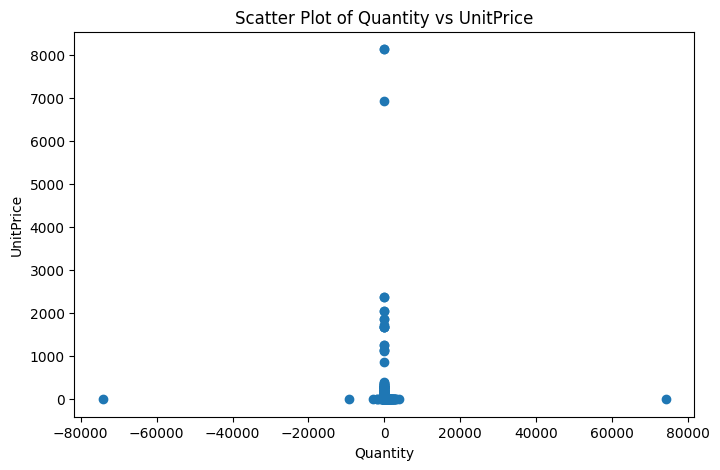

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'],df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.show()

In [27]:
x=df[['Quantity','UnitPrice']]
y=df['Country_encoded']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

print("Logistic Regression")
log_model =LogisticRegression()
log_model.fit(x_train,y_train)
y_pred=log_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix::")
print(cm)

print("Decision Tree")
dt_model=DecisionTreeClassifier()
dt_model.fit(x_train,y_train)
y_pred=dt_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test,y_pred))

print("KNN")
knn_model=KNeighborsClassifier()
knn_model.fit(x_train,y_train)
y_pred=knn_model.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)
print(confusion_matrix(y_test,y_pred))

Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8946152068407672
Confusion Matrix::
[[    0     0     0 ...     0    70     0]
 [    0     0     0 ...     0    15     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0     8     0]
 [    0     0     0 ...     0 23226     0]
 [    0     0     0 ...     0    13     0]]
Decision Tree
Accuracy: 0.8958477775209922
[[    6     0     0 ...     0    60     0]
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0     8     0]
 [   20     0     0 ...     0 23163     0]
 [    0     0     0 ...     0    13     0]]
KNN
Accuracy: 0.8816346968646483
[[    4     0     0 ...     0    61     0]
 [    0     0     0 ...     0    13     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0     8     0]
 [   24     0     0 ...     0 22796     0]
 [    0     0     0 ...     0    13     0]]


In [28]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]
accuracies=[
    accuracy,
    accuracy,
    accuracy]

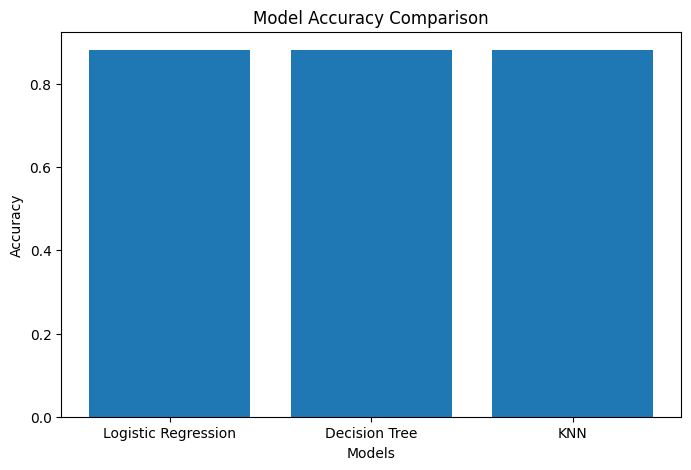

In [29]:
plt.figure(figsize=(8,5))
plt.bar(models,accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()